# Data Cleaning and Basic Visualization
## Week 1 Task - Vortex Tech Internship

In [3]:
#import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Dataset load
df = pd.read_csv('sales_dataset.csv')
print(df.head())
print(df.tail())

   Order_ID  Order_Date Region     Category    Sales  Quantity Customer_Age  \
0     10001  2024-10-16  North  Electronics  3710.34         4           32   
1     10002  2023-04-15  North    Groceries    168.6         2           31   
2     10003  2024-06-01  North    Furniture  3582.94         9           44   
3     10004  2024-04-04   East  Electronics  3796.45         3           62   
4     10005  2023-12-15   East    Furniture  1084.42         6           24   

  Payment_Method  
0           Card  
1           Card  
2           Card  
3  Bank Transfer  
4           Cash  
      Order_ID  Order_Date Region   Category    Sales  Quantity Customer_Age  \
1015     10016  2024-01-06  South  Furniture  2552.54         2           66   
1016     10017  2023-04-23  South  Furniture  3962.48         7           56   
1017     10018  2024-01-30   West  Groceries  2650.28         9           18   
1018     10019  2024-11-29   East   Clothing   566.65         7           28   
1019     10

# Data Cleaning
This section identifies and handles duplicate records, missing values, and incorrect data types before analysis.

In [5]:
#Data Cleaning
print(df.shape)
print(df.columns)
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df.isnull().sum())
print(df.info())
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Region'] = df['Region'].fillna('Unknown')
df['Sales'] = pd.to_numeric(df['Sales'], errors= 'coerce')
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
print(df['Customer_Age'].unique())
df['Customer_Age'] = df['Customer_Age'].replace('Unknown', np.nan)
df['Customer_Age'] = pd.to_numeric(df['Customer_Age'], errors= 'coerce')
df['Customer_Age'] = df['Customer_Age'].fillna(df['Customer_Age'].median())
df['Customer_Age'] = df['Customer_Age'].round().astype(int)
df['Payment_Method'] = df['Payment_Method'].fillna('Unknown')

(1020, 8)
Index(['Order_ID', 'Order_Date', 'Region', 'Category', 'Sales', 'Quantity',
       'Customer_Age', 'Payment_Method'],
      dtype='str')
20
Order_ID           0
Order_Date         0
Region            30
Category           0
Sales             39
Quantity           0
Customer_Age       0
Payment_Method    25
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Order_ID        1000 non-null   int64
 1   Order_Date      1000 non-null   str  
 2   Region          970 non-null    str  
 3   Category        1000 non-null   str  
 4   Sales           961 non-null    str  
 5   Quantity        1000 non-null   int64
 6   Customer_Age    1000 non-null   str  
 7   Payment_Method  975 non-null    str  
dtypes: int64(2), str(6)
memory usage: 62.6 KB
None
<StringArray>
[     '32',      '31',      '44',      '62',      '24',      '34',      '58',
 

# Data Visualization
# Visualization 1. Sales by Category

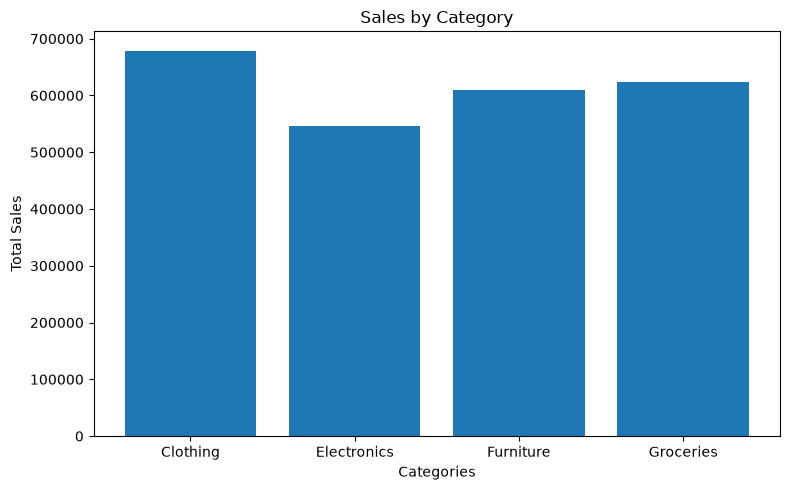

In [6]:
#Sales by Category
sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(8,5))
plt.bar(sales.index, sales.values)
plt.title('Sales by Category')
plt.xlabel('Categories')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('sales_by_category.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

### What does this chart show?
This bar chart compares the total sales generated by each product category.

### Insight
The **Clothing** category generated the highest sales, while **Electronics** had the lowest. This indicates that Electronics is the strongest revenue contributor and may deserve additional marketing focus.

# Visualization 2. Monthly Sales Trend

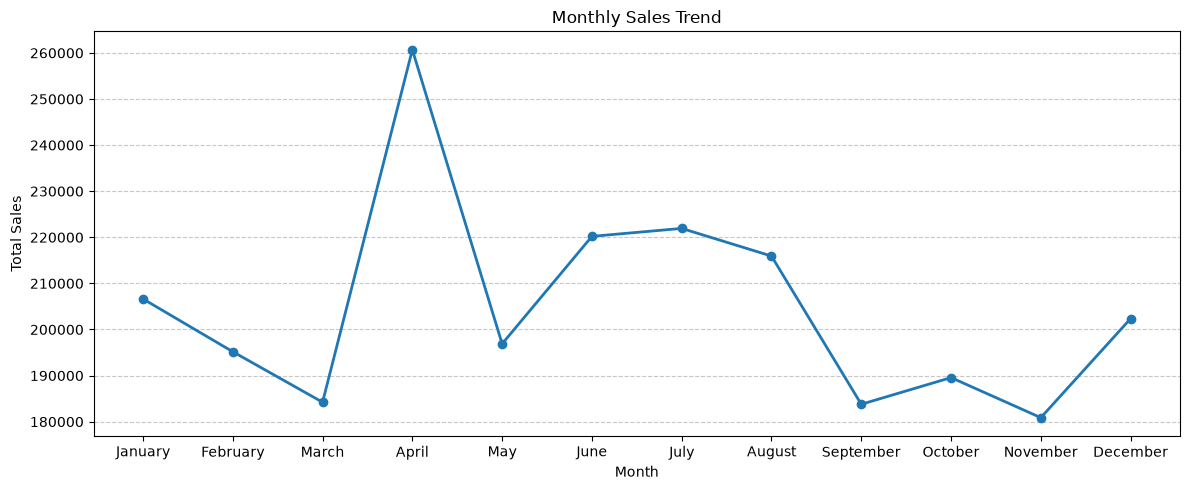

In [7]:
# Monthly Sales Trend
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
df['Month'] = df['Order_Date'].dt.month_name()
monthly_sales = (df.groupby('Month')['Sales'].sum().reindex(month_order))
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('monthly_sales_trend.pdf', dpi=300, bbox_inches='tight')
plt.show()

### What does this chart show?
This line chart illustrates how total sales changed from month to month.

### Insight
Sales fluctuate throughout the year, with noticeable peaks in certain months. These peaks may indicate seasonal demand or promotional periods.

# Visualization 3. Orders by Payment Method

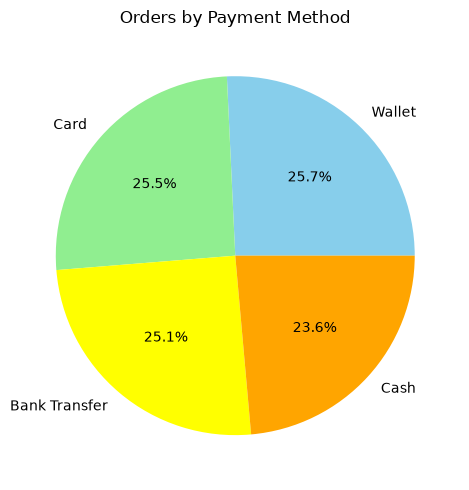

In [8]:
#Orders by Payment Method
orders = df[df['Payment_Method'] != 'Unknown']['Payment_Method'].value_counts()
plt.figure(figsize=(8,5))
plt.pie(orders.values, labels=orders.index, autopct='%1.1f%%', colors= ['skyblue', 'lightgreen', 'yellow', 'orange'])
plt.title('Orders by Payment Method')
plt.tight_layout()
plt.savefig('orders_by_payment_method.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

### What does this chart show?
This pie chart displays the percentage of orders completed using each payment method.

### Insight
Most customers prefer **Wallet** payments, suggesting that digital payment methods are widely adopted.

# Visualization 4. Sales Distribution

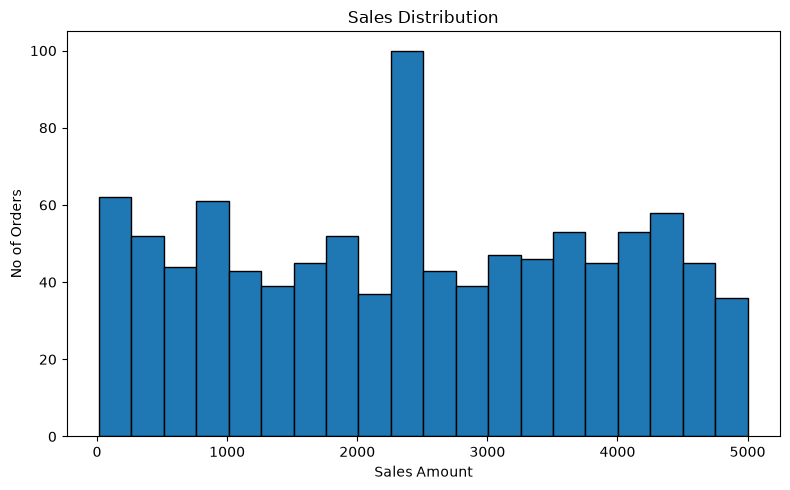

In [9]:
#Sales Distribution
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=20, edgecolor='black')
plt.title('Sales Distribution')
plt.xlabel('Sales Amount')
plt.ylabel('No of Orders')
plt.tight_layout()
plt.savefig('sales_distribution.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

### What does this chart show?
This histogram shows how sales amounts are distributed across all orders.

### Insight
Sales are spread across different ranges, with a slight peak around 2,300–2,500, showing a balanced distribution of order values.

# Visualization 5. Sales by Region

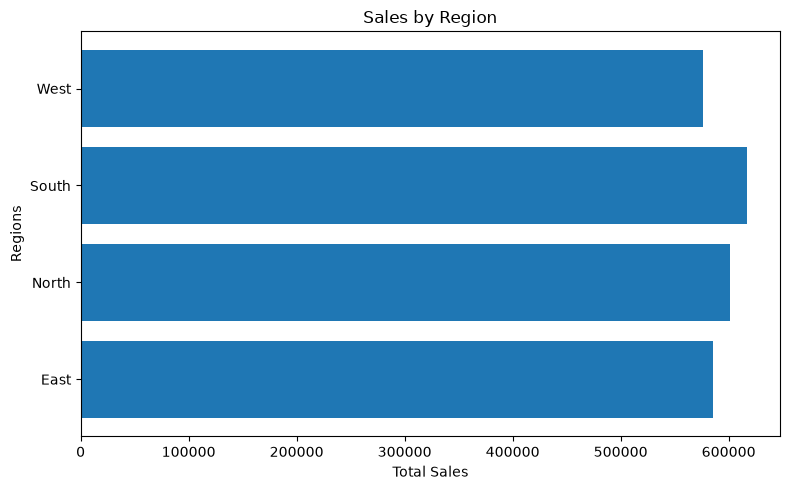

In [10]:
region_sale = df.groupby(df[df['Region'] != 'Unknown']['Region'])['Sales'].sum()
plt.figure(figsize=(8,5))
plt.barh(region_sale.index, region_sale.values)
plt.title('Sales by Region')
plt.xlabel('Total Sales')
plt.ylabel('Regions')
plt.tight_layout()
plt.savefig('region_sale.pdf', dpi= 300, bbox_inches= 'tight')
plt.show()

### What does this chart show?
This horizontal bar chart compares total sales across different regions.

### Insight
The **South** region recorded the highest sales, while the **West** region generated comparatively lower revenue. This information can help identify high-performing markets.